<a href="https://colab.research.google.com/github/satyam-tomar/Supervised_Learning/blob/Fixing-Errors/SpanEmailDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Dataset

In [ ]:
import numpy as np
import pandas as pd

try:
  df = pd.read_csv("emails.csv")

  if not df.empty:
    print("Data imported Successfully")
  else:
    print("Data is not imported there is an error")
except Exception as e:
  print(e)

Data imported Successfully


#Data Analysis

First check how does our data looks like then we will move forward in the data cleaning process.

In [ ]:
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


Check the shape of the dataframe.

In [ ]:
df.shape

(5172, 3002)

 Check weather the dataset is balanced or not.

In [ ]:
print(df["Prediction"].value_counts())
print(df['Prediction'].value_counts(normalize=True))


Prediction
0    3672
1    1500
Name: count, dtype: int64
Prediction
0    0.709977
1    0.290023
Name: proportion, dtype: float64


 It is clearly seen that the data is imbalance 71% for 0 values and 1 for 29%. Let's remove the duplicate rows then check.

In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df["Prediction"].value_counts())
print(df['Prediction'].value_counts(normalize=True))

Prediction
0    3672
1    1500
Name: count, dtype: int64
Prediction
0    0.709977
1    0.290023
Name: proportion, dtype: float64


It seems that the shape is still same, means there is no duplicate row in the data. Now let's try to another approach, let's remove the rows where the target value is null.

In [ ]:
df = df.dropna(subset=["Prediction"])
print(df["Prediction"].value_counts())

Prediction
0    3672
1    1500
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Target Values')

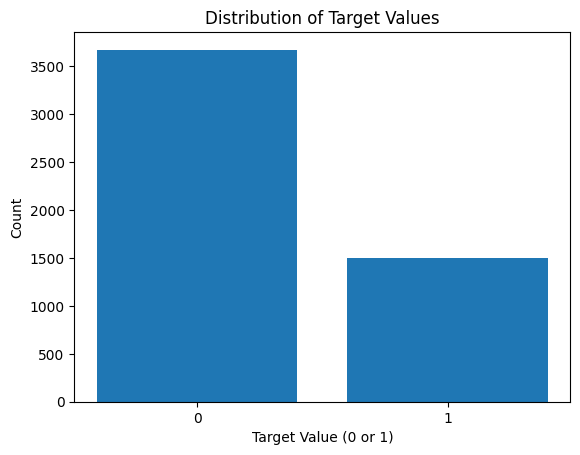

In [ ]:
import matplotlib.pyplot as plt

counts = df['Prediction'].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Target Value (0 or 1)")
plt.ylabel("Count")
plt.title("Distribution of Target Values")


We have observed that after removing the duplicate rows and deleting the rows where the target value is null then also the data is imbalance. Now we are going to use SMOTE to make our data balance, we are using SMOTE because our dataset is having numerical values, which is best for SMOTE to make it balance.

So drop the column => Prediction_class first and then move forward.

In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop(['Email No.', 'Prediction'], axis=1)
y = df['Prediction']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Combine into a new dataframe if needed
df_balanced = pd.DataFrame(X_res, columns=X.columns)
df_balanced['Prediction'] = y_res

print(df_balanced['Prediction'].value_counts())


Prediction
0    3672
1    3672
Name: count, dtype: int64


/tmp/ipython-input-608611469.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_balanced['Prediction'] = y_res


Text(0.5, 1.0, 'Distribution of Target Values')

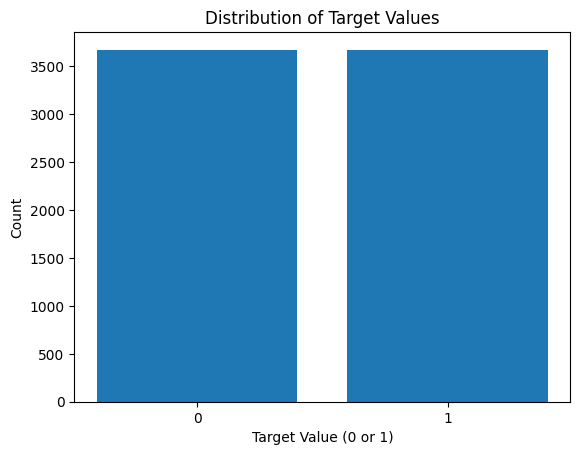

In [ ]:
import matplotlib.pyplot as plt

counts = df_balanced['Prediction'].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Target Value (0 or 1)")
plt.ylabel("Count")
plt.title("Distribution of Target Values")

After applying SMOTE we can observe that the number of spam email and number of non spam emails are equal now are dataset is imbalanced.

In [ ]:
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
df_balanced.head()

,the,to,ect,and,for,of,a,you,hou,in,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
print(list(df.columns))

['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'net', 'followin

In [ ]:
print(df["Prediction"].value_counts())
print(df_balanced["Prediction"].value_counts())
print(df['Prediction'].value_counts(normalize=True))
print(df_balanced["Prediction"].value_counts(normalize=True))

Prediction
0    3672
1    1500
Name: count, dtype: int64
Prediction
0    3672
1    3672
Name: count, dtype: int64
Prediction
0    0.709977
1    0.290023
Name: proportion, dtype: float64
Prediction
0    0.5
1    0.5
Name: proportion, dtype: float64


Now here we are having our dataset properly balanced.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
X = df_balanced.drop(["Prediction"], axis=1)
y = df_balanced["Prediction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)




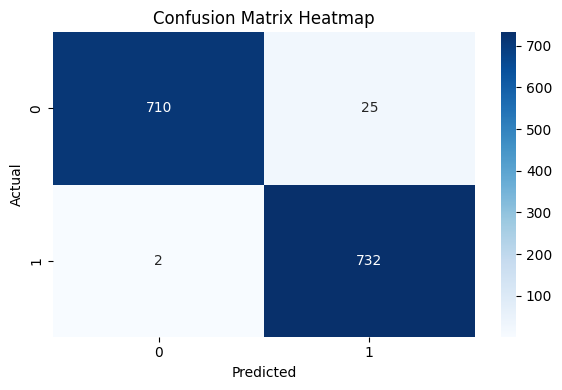

In [ ]:
import seaborn as sns

y_true = y_test

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Model metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Accuracy: 0.9816
Precision: 0.9670
Recall: 0.9973


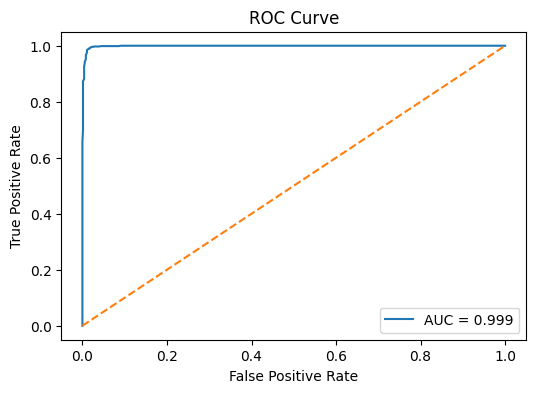

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_test = actual labels
y_pred_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
